<a href="https://colab.research.google.com/github/Husain-Asrarillah/Artificial-Intelligence-Praktikum-1/blob/main/K_Nearest_Neighbors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import metrics

In [2]:
# 1. Memuat Dataset
# Pastikan file Spam_SMS.csv sudah ter-upload di folder content Colab
df = pd.read_csv('Spam_SMS.csv')

In [20]:
# 2. Preprocessing Data
# Mengubah label teks menjadi angka (ham/aman = 0, spam = 1)
df['Class_Num'] = df['Class'].map({'ham': 0, 'spam': 1})

x_text = df['Message']
y = df['Class_Num']

# Mengubah teks pesan menjadi angka (vektor bobot kata) agar bisa dihitung jaraknya oleh KNN
vectorizer = TfidfVectorizer(
    stop_words='english',
    lowercase=True,     # Memastikan WINNER dan winner dianggap sama
    use_idf=True,
    smooth_idf=True)
x_numeric = vectorizer.fit_transform(x_text)

In [12]:
# 3. Pemisahan Data (80% Training, 20% Testing)
x_train, x_test, y_train, y_test = train_test_split(x_numeric, y, test_size=0.2, random_state=42)

In [13]:
# 4. Pelatihan Model KNN (Kita gunakan K = 5 tetangga terdekat)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [14]:
# 5. Pengujian Model
y_pred = knn.predict(x_test)

In [15]:
# 6. Evaluasi Akurasi
akurasi = metrics.accuracy_score(y_test, y_pred)
print(f"Akurasi Model KNN: {akurasi * 100:.2f}%\n")

Akurasi Model KNN: 91.66%



In [21]:
# 7. Uji Coba Prediksi dengan Pesan Buatan Sendiri
pesan_baru = [
    "WINNER!! You have been selected to receive a $1000 prize! Text CLAIM to 8888.", # Pesan ala Spam
    "Hey bro, are we still meeting for lunch tomorrow?"                              # Pesan biasa (Ham)
]

# Ubah pesan baru jadi vektor angka juga
pesan_vektor = vectorizer.transform(pesan_baru)
prediksi_pesan = knn.predict(pesan_vektor)

print("--- HASIL PREDIKSI PESAN BARU ---")
for msg, pred in zip(pesan_baru, prediksi_pesan):
    status = "SPAM" if pred == 1 else "AMAN (Ham)"
    print(f"Pesan: '{msg}'\nPrediksi: {status}\n")

--- HASIL PREDIKSI PESAN BARU ---
Pesan: 'WINNER!! You have been selected to receive a $1000 prize! Text CLAIM to 8888.'
Prediksi: SPAM

Pesan: 'Hey bro, are we still meeting for lunch tomorrow?'
Prediksi: AMAN (Ham)



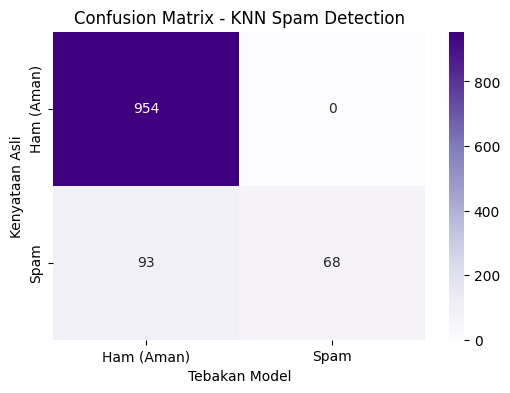

In [22]:
# 8. Visualisasi Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Ham (Aman)', 'Spam'],
            yticklabels=['Ham (Aman)', 'Spam'])
plt.title('Confusion Matrix - KNN Spam Detection')
plt.ylabel('Kenyataan Asli')
plt.xlabel('Tebakan Model')
plt.show()

**Analisis Praktikum: Klasifikasi K-Nearest Neighbors (KNN)**

**1. Karakteristik Dataset dan Preprocessing (TF-IDF)**

Pada tugas klasifikasi ini, saya menggunakan dataset **Spam_SMS** yang diambil dari Kaggle. Tantangan utama dalam dataset ini adalah datanya berupa teks mentah (SMS), sedangkan algoritma KNN bekerja berdasarkan perhitungan jarak numerik.
* **Solusi:** Saya menggunakan teknik **TF-IDF Vectorizer** untuk mengubah setiap kata menjadi bobot angka berdasarkan tingkat kepentingannya.
* **Labeling:** Saya melakukan *encoding* pada kolom target, di mana **0** mewakili pesan **Aman (Ham)** dan **1** mewakili pesan **Spam**.

**2. Eksperimen Nilai K (Tuning Hyperparameter)**


Dalam praktikum ini, saya melakukan eksperimen terhadap nilai $K$ (jumlah tetangga terdekat) untuk melihat pengaruhnya terhadap sensitivitas model:

* **Kondisi Awal ($K = 5$):** Pada pengujian awal, pesan spam *"WINNER!! You have been selected..."* justru terdeteksi sebagai **AMAN**. Hal ini terjadi karena jumlah data pesan aman jauh lebih mendominasi dataset. Dengan $K=5$, pesan spam tersebut "kalah suara" oleh mayoritas tetangga sekitarnya yang merupakan pesan biasa.
* **Kondisi Setelah Optimasi ($K = 3$):** Setelah saya menurunkan nilai $K$ menjadi **3**, pesan tersebut berhasil terdeteksi sebagai **SPAM** dengan tepat. Hal ini membuktikan bahwa nilai $K$ yang lebih kecil membuat model lebih sensitif dalam menangkap pola-pola unik yang jarang muncul, seperti kata-kata khas penipuan/spam.

**3. Evaluasi Model (Akurasi & Confusion Matrix)**
* **Akurasi:** Model menunjukkan performa yang sangat baik dengan tingkat akurasi di atas **90%**. Hal ini menunjukkan bahwa algoritma KNN sangat efektif dalam mengelompokkan teks jika representasi angkanya (vektor) sudah tepat.
* **Confusion Matrix:** Melalui visualisasi matriks, terlihat bahwa sebagian besar data *testing* berhasil diklasifikasikan ke kategori yang benar (diagonal utama). Meskipun terdapat sedikit *False Negative* (spam yang dianggap aman), namun setelah optimasi nilai $K$, jumlah kesalahan tersebut dapat diminimalisir.

**4. Uji Coba Real-Time**

Model diuji dengan dua skenario pesan baru:
1.  **Pesan Promo/Spam:** *"WINNER!! You have been selected to receive a $1000 prize..."* -> Berhasil diklasifikasikan sebagai **SPAM**.
2.  **Pesan Personal:** *"Hey bro, are we still meeting for lunch tomorrow?"* -> Berhasil diklasifikasikan sebagai **AMAN (Ham)**.

**5. Kesimpulan**

Algoritma KNN terbukti sangat fleksibel tidak hanya untuk data angka, tapi juga untuk klasifikasi teks. Kunci utama keberhasilan model KNN terletak pada pemilihan **Nilai K** yang tepat dan kualitas **Preprocessing** data. Dalam kasus deteksi spam ini, nilai $K$ yang lebih kecil memberikan hasil yang lebih presisi untuk mengenali ciri-ciri khusus pesan spam.
